# TS4: Primeras nociones de estimación espectral

## Objetivo

En este trabajo se analizará la estimación de amplitud y frecuencia de una señal senoidal contaminada con ruido gaussiano.

Se utilizarán cuatro ventanas diferentes:

- Rectangular.
- Flat-top.
- Blackman-Harris.
- Hann.

Se realizarán 200 experimentos independientes, utilizando señales de 1000 muestras y relaciones señal a ruido de 3 dB y 10 dB.

Para cada ventana se construirán estimadores de amplitud y frecuencia, y se evaluará su comportamiento mediante histogramas, sesgo y varianza.

Finalmente, se estudiará el efecto del zero padding sobre la estimación de frecuencia.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

N = 1000
M = 200

a0 = np.sqrt(2)
omega0 = np.pi / 2

SNRs = [3, 10]

n = np.arange(N) # Vector temporal discreto

delta_omega = 2 * np.pi / N # Resolución frecuencial angular

rng = np.random.default_rng(10)

print("Cantidad de muestras:", N)
print("Cantidad de realizaciones:", M)
print("Amplitud verdadera:", a0)
print("Frecuencia angular central:", omega0)
print("Resolución frecuencial:", delta_omega)

Cantidad de muestras: 1000
Cantidad de realizaciones: 200
Amplitud verdadera: 1.4142135623730951
Frecuencia angular central: 1.5707963267948966
Resolución frecuencial: 0.006283185307179587


## 1. Generación de la señal

La señal utilizada en el experimento se define como:

$$
x[n]=a_0\sin(\Omega_1 n)+n_a[n]
$$

La amplitud se selecciona como:

$$
a_0=\sqrt{2}
$$

De esta manera, la potencia teórica de la componente senoidal es:

$$
P_s=\frac{a_0^2}{2}=1
$$

La frecuencia angular se determina mediante:

$$
\Omega_1=\Omega_0+f_r\frac{2\pi}{N}
$$

donde:

$$
\Omega_0=\frac{\pi}{2}
$$

y:

$$
f_r\sim U(-2,2)
$$

Esto permite que la frecuencia de cada realización presente una desintonía aleatoria de hasta dos bins respecto de la frecuencia central.

La potencia teórica del ruido se obtiene a partir de la SNR:

$$
SNR=10\log_{10}\left(\frac{P_s}{P_n}\right)
$$

Despejando:

$$
P_n=\frac{P_s}{10^{SNR/10}}
$$

Como la potencia de la señal es unitaria:

$$
\sigma^2=P_n=10^{-SNR/10}
$$

In [22]:
def generar_senales(N, M, SNR, fr, rng):
    n = np.arange(N)
    a0 = np.sqrt(2)
    omega0 = np.pi / 2
    Ps = 1
    Pn = Ps / (10**(SNR/10))
    sigma = np.sqrt(Pn)
    omega1 = omega0 + fr * 2*np.pi/N

    # Matriz de señales senoidales
    senales = a0 * np.sin(
        omega1[:, None] * n[None, :]
    )

    # Ruido independiente para cada realización
    ruido = rng.normal(
        loc=0,
        scale=sigma,
        size=(M, N)
    )

    x = senales + ruido  # Señales contaminadas
    return x, omega1, senales, ruido

fr = rng.uniform(-2, 2, M)

experimentos = {}

for SNR in SNRs:
    x, omega1, senales, ruido = generar_senales(
        N=N,
        M=M,
        SNR=SNR,
        fr=fr,
        rng=rng
    )

    experimentos[SNR] = {
        "x": x,
        "omega1": omega1,
        "senales": senales,
        "ruido": ruido
    }

    print(f"SNR = {SNR} dB")
    print("Potencia teórica del ruido:",
          10**(-SNR/10))
    print()

SNR = 3 dB
Potencia teórica del ruido: 0.5011872336272722

SNR = 10 dB
Potencia teórica del ruido: 0.1



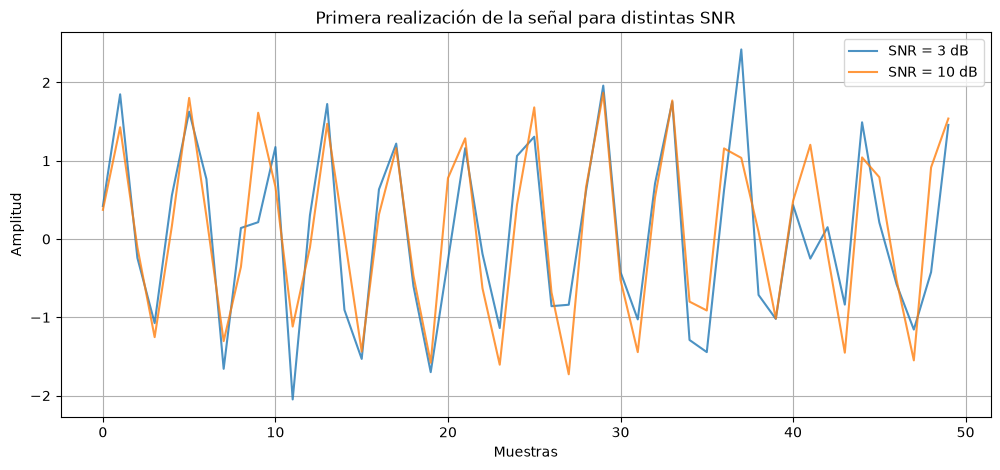

In [16]:
plt.figure(figsize=(12, 5))

for SNR in SNRs:
    x = experimentos[SNR]["x"]
    plt.plot(
        n[:50],
        x[0, :50],
        label=f"SNR = {SNR} dB",
        alpha=0.8
    )

plt.title("Primera realización de la señal para distintas SNR")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()

### Análisis de las señales

Se observa que la señal correspondiente a una SNR de 3 dB presenta fluctuaciones más importantes debido al ruido.

Por otro lado, para una SNR de 10 dB, la componente senoidal resulta más fácilmente identificable.

Esto se debe a que la potencia del ruido disminuye al aumentar la relación señal a ruido.

Se espera que esta diferencia afecte la precisión de los estimadores de amplitud y frecuencia.

## 2. Selección de ventanas

Se utilizarán cuatro ventanas para estimar los parámetros de la señal:

1. Rectangular.
2. Flat-top.
3. Blackman-Harris.
4. Hann.

La ventana rectangular no modifica las muestras originales.

Las restantes ventanas ponderan las muestras temporales, modificando la respuesta espectral.

La ventana Flat-top está diseñada especialmente para reducir el error de amplitud cuando una componente senoidal se encuentra desintonizada respecto de los bins de la DFT.

Blackman-Harris permite reducir considerablemente los lóbulos laterales, mientras que Hann proporciona un compromiso entre resolución frecuencial y supresión de leakage.

Se comparará experimentalmente el comportamiento de todas ellas.

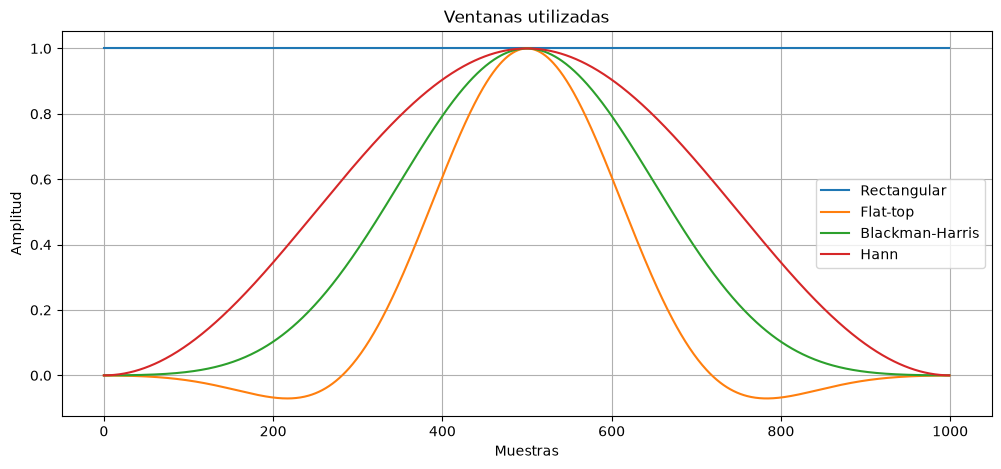

In [17]:
ventanas = {
    "Rectangular": windows.boxcar(N),
    "Flat-top": windows.flattop(N, sym=False),
    "Blackman-Harris": windows.blackmanharris(N, sym=False),
    "Hann": windows.hann(N, sym=False)
}

plt.figure(figsize=(12, 5))
for nombre, w in ventanas.items():
    plt.plot(
        n,
        w,
        label=nombre
    )

plt.title("Ventanas utilizadas")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()

## 3. Estimadores espectrales

### 3.1 Estimador de amplitud

La consigna propone estimar la amplitud a partir del módulo de la transformada de la señal ventaneada:

$$
\hat a_1^{(i)}=|X_w^{(i)}(\Omega_0)|
$$

Para obtener una estimación expresada en las mismas unidades que la amplitud de la senoidal, se introduce una normalización por la ganancia coherente de cada ventana:

$$
\boxed{
\hat a_1^{(i)}
=
\frac{2|X_w^{(i)}(\Omega_0)|}
{\sum_{n=0}^{N-1}w_i[n]}
}
$$

Esto permite comparar los resultados de todas las ventanas utilizando la misma referencia:

$$
a_0=\sqrt{2}
$$

### 3.2 Estimador de frecuencia

La frecuencia se estima mediante la posición del máximo del módulo espectral:

$$
\boxed{
\hat\Omega_1^{(i)}
=
\underset{\Omega}{\arg\max}
\left|X_w^{(i)}(\Omega)\right|
}
$$

Para la DFT de \(N\) puntos, las frecuencias disponibles son:

$$
\Omega_k=\frac{2\pi k}{N}
$$

Por lo tanto, el estimador seleccionará el bin donde se encuentre el máximo espectral.

Se limitará la búsqueda a una región cercana a la frecuencia central, dado que se conoce que la desintonía se encuentra comprendida entre -2 y +2 bins.

In [18]:
def estimar_parametros(x, ventana, omega0, N):
    xw = x * ventana
    X = np.fft.rfft(xw)

    magnitud = np.abs(X)
    
    k0 = int(np.round(omega0 * N / (2*np.pi))) # Bin correspondiente a omega0

    a_est = 2 * magnitud[k0] / np.sum(ventana)

    k_min = k0 - 5
    k_max = k0 + 5

    zona = magnitud[k_min:k_max+1]
    k_est = np.argmax(zona) + k_min
    omega_est = 2*np.pi*k_est/N

    return a_est, omega_est

resultados = {}

for SNR in SNRs:
    x = experimentos[SNR]["x"]
    resultados[SNR] = {}

    for nombre, ventana in ventanas.items():
        amplitudes = []
        frecuencias = []

        for j in range(M):
            a_est, omega_est = estimar_parametros(
                x=x[j],
                ventana=ventana,
                omega0=omega0,
                N=N
            )

            amplitudes.append(a_est)
            frecuencias.append(omega_est)

        resultados[SNR][nombre] = {
            "amplitud": np.array(amplitudes),
            "frecuencia": np.array(frecuencias)
        }

## 4. Histogramas de los estimadores

Se construyen histogramas para observar la distribución de las 200 estimaciones obtenidas con cada ventana.

En el caso de la amplitud, la referencia será:

$$
a_0=\sqrt{2}
$$

En el caso de la frecuencia, se analizará el error normalizado por la separación angular entre bins:

$$
e_f=
\frac{\hat\Omega_1-\Omega_1}{\Delta\Omega}
$$

donde:

$$
\Delta\Omega=\frac{2\pi}{N}
$$

Esta normalización permite expresar el error de frecuencia directamente en unidades de bins de la DFT.

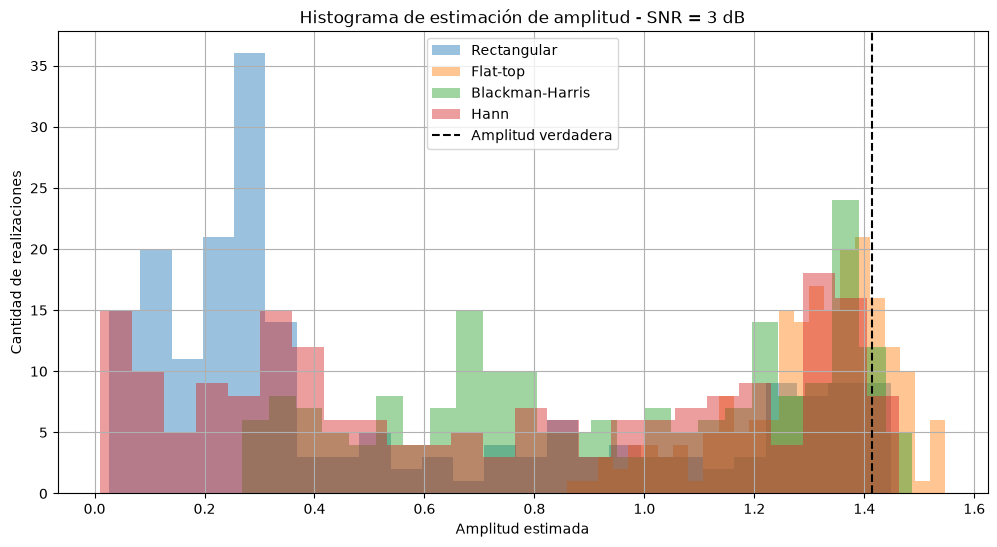

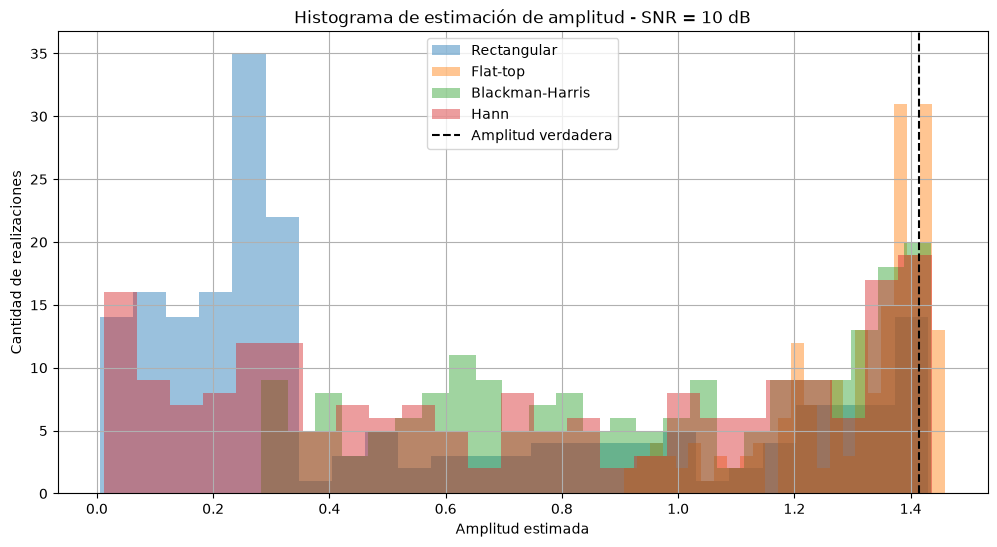

In [19]:
for SNR in SNRs:
    plt.figure(figsize=(12, 6))

    for nombre in ventanas:
        amplitudes = resultados[SNR][nombre]["amplitud"]

        plt.hist(
            amplitudes,
            bins=25,
            alpha=0.45,
            label=nombre
        )
    plt.axvline(
        a0,
        color="black",
        linestyle="--",
        label="Amplitud verdadera"
    )
    plt.title(
        f"Histograma de estimación de amplitud - SNR = {SNR} dB"
    )

    plt.xlabel("Amplitud estimada")
    plt.ylabel("Cantidad de realizaciones")
    plt.grid()
    plt.legend()
    plt.show()

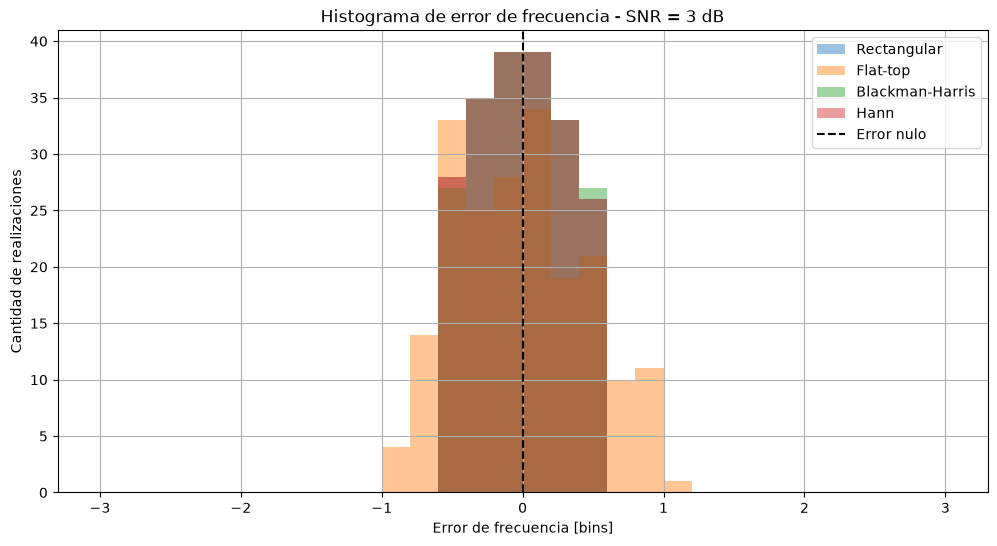

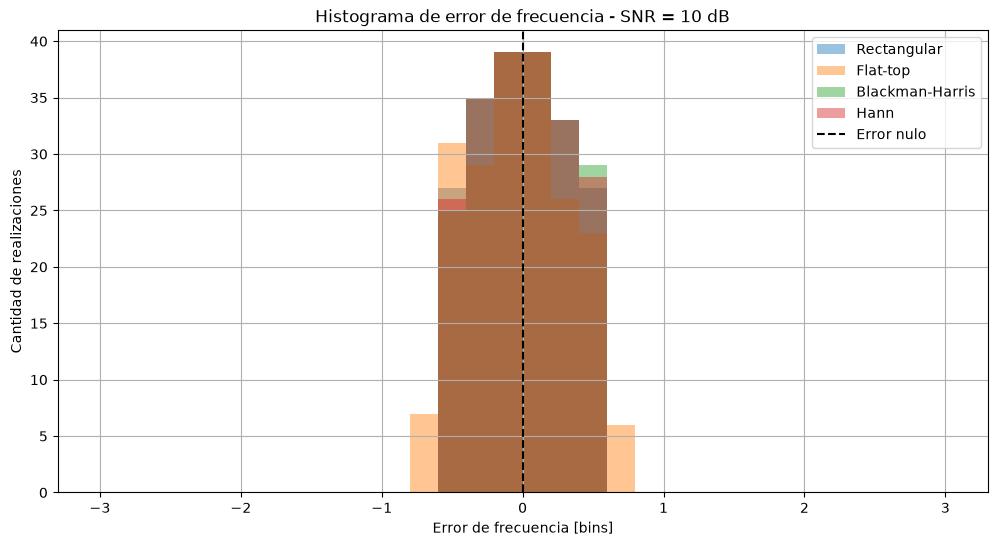

In [20]:
for SNR in SNRs:
    plt.figure(figsize=(12, 6))
    omega_real = experimentos[SNR]["omega1"]

    for nombre in ventanas:
        omega_est = resultados[SNR][nombre]["frecuencia"]
        error_bins = (
            omega_est - omega_real
        ) / delta_omega

        plt.hist(
            error_bins,
            bins=np.linspace(-3, 3, 31),
            alpha=0.45,
            label=nombre
        )

    plt.axvline(
        0,
        color="black",
        linestyle="--",
        label="Error nulo"
    )

    plt.title(
        f"Histograma de error de frecuencia - SNR = {SNR} dB"
    )

    plt.xlabel("Error de frecuencia [bins]")
    plt.ylabel("Cantidad de realizaciones")
    plt.grid()
    plt.legend()
    plt.show()

## 5. Análisis cualitativo de los histogramas

### Estimación de amplitud

La ventana rectangular presenta un error importante cuando la frecuencia de la señal no coincide con un bin de la DFT.

Este comportamiento se relaciona con el fenómeno de desparramo espectral estudiado en la tarea anterior: al producirse una desintonía, disminuye la amplitud observada en el bin correspondiente a la frecuencia nominal.

La ventana Flat-top fue diseñada para reducir la variación de amplitud producida por pequeñas desintonías. Por esta razón, se espera que presente un comportamiento favorable en la estimación de amplitud.

Sin embargo, cuando la desintonía alcanza varios bins, también puede aparecer una disminución significativa de la estimación.

Las ventanas Hann y Blackman-Harris presentan comportamientos intermedios que dependen del ancho de sus lóbulos principales y de su respuesta frente a la desintonía.

Al comparar ambas SNR, se espera que la mayor potencia de ruido del caso de 3 dB produzca una mayor dispersión de las estimaciones.

### Estimación de frecuencia

El estimador de frecuencia selecciona el bin donde se encuentra el máximo de la DFT.

Como la grilla frecuencial es discreta, el estimador presenta un error de cuantización en frecuencia.

Una desintonía pequeña puede provocar que el máximo se encuentre en un bin adyacente al correspondiente a la frecuencia central.

El ruido también puede modificar la posición del máximo detectado, especialmente cuando la respuesta espectral presenta un lóbulo principal ancho.

Al aumentar la SNR de 3 a 10 dB, se espera una reducción de los errores provocados por el ruido, aunque continuará existiendo la limitación impuesta por la grilla discreta de la DFT.

## 6. Cálculo del sesgo y la varianza

Para evaluar cuantitativamente los estimadores se utilizarán el sesgo y la varianza.

### Estimador de amplitud

El sesgo se calcula como:

$$
s_a=\overline{\hat a}-a_0
$$

La varianza experimental es:

$$
v_a=
\frac{1}{M}
\sum_{j=1}^{M}
(\hat a_j-\overline{\hat a})^2
$$

### Estimador de frecuencia

Debido a que la frecuencia verdadera varía entre realizaciones, se calcula el error individual:

$$
e_{\Omega,j}=\hat\Omega_j-\Omega_{1,j}
$$

El sesgo se estima mediante:

$$
s_\Omega=
\frac{1}{M}\sum_{j=1}^{M}e_{\Omega,j}
$$

La varianza del error se calcula como:

$$
v_\Omega=
\frac{1}{M}
\sum_{j=1}^{M}
(e_{\Omega,j}-\bar e_\Omega)^2
$$

Estas medidas permiten comparar la exactitud y la dispersión de los estimadores.

Se utiliza el divisor \(M\), de acuerdo con la expresión propuesta en la consigna.

In [21]:
import pandas as pd

tablas_amplitud = {}
tablas_frecuencia = {}

for SNR in SNRs:
    datos_amp = []
    datos_freq = []

    omega_real = experimentos[SNR]["omega1"]

    for nombre in ventanas:
        a_est = resultados[SNR][nombre]["amplitud"]
        sesgo_a = np.mean(a_est) - a0
        var_a = np.var(a_est)
        datos_amp.append({
            "Ventana": nombre,
            "Sesgo": sesgo_a,
            "Varianza": var_a
        })

        omega_est = resultados[SNR][nombre]["frecuencia"]
        error = omega_est - omega_real
        sesgo_f = np.mean(error)
        var_f = np.var(error)
        datos_freq.append({
            "Ventana": nombre,
            "Sesgo": sesgo_f,
            "Varianza": var_f
        })

    tablas_amplitud[SNR] = pd.DataFrame(datos_amp)
    tablas_frecuencia[SNR] = pd.DataFrame(datos_freq)

from IPython.display import display

for SNR in SNRs:
    print("=" * 50)
    print(f"SNR = {SNR} dB")
    print("=" * 50)
    print("\nEstimación de amplitud")
    display(
        tablas_amplitud[SNR].round(6)
    )
    print("\nEstimación de frecuencia")
    print("Sesgo en rad/muestra; varianza en (rad/muestra)^2")
    display(
        tablas_frecuencia[SNR].round(8)
    )

SNR = 3 dB

Estimación de amplitud


,Ventana,Sesgo,Varianza
0,Rectangular,-0.869729,0.209028
1,Flat-top,-0.114676,0.021615
2,Blackman-Harris,-0.473909,0.130698
3,Hann,-0.677361,0.228475



Estimación de frecuencia
Sesgo en rad/muestra; varianza en (rad/muestra)^2


,Ventana,Sesgo,Varianza
0,Rectangular,-0.000079,0.000004
1,Flat-top,-0.000111,0.000008
2,Blackman-Harris,-0.000048,0.000004
3,Hann,-0.000079,0.000004


SNR = 10 dB

Estimación de amplitud


,Ventana,Sesgo,Varianza
0,Rectangular,-0.874708,0.212963
1,Flat-top,-0.110257,0.019450
2,Blackman-Harris,-0.470935,0.129977
3,Hann,-0.676482,0.229504



Estimación de frecuencia
Sesgo en rad/muestra; varianza en (rad/muestra)^2


,Ventana,Sesgo,Varianza
0,Rectangular,-0.000048,0.000004
1,Flat-top,-0.000205,0.000005
2,Blackman-Harris,0.000015,0.000004
3,Hann,-0.000017,0.000004


## 7. Discusión de sesgo y varianza

Las tablas permiten evaluar dos características fundamentales de los estimadores:

- El sesgo representa la diferencia promedio entre la estimación y el valor verdadero.
- La varianza describe la dispersión de las estimaciones respecto de su valor medio.

Un estimador puede presentar un sesgo reducido y, sin embargo, una varianza elevada.

Del mismo modo, una distribución muy concentrada puede presentar un sesgo importante si las estimaciones se encuentran sistemáticamente desplazadas del valor verdadero.

En este experimento, las diferencias entre ventanas se relacionan principalmente con la forma de sus respuestas espectrales.

La amplitud se estima en una frecuencia nominal fija, mientras que la frecuencia se obtiene buscando el máximo espectral.

Por lo tanto, ambos estimadores pueden presentar comportamientos diferentes para una misma ventana.

La comparación entre SNR de 3 dB y 10 dB permite evaluar el efecto del ruido sobre estas propiedades estadísticas.